## Needleman-Wunsch-Alignment


This algorithm is used to calculate a biologically relevant global alignment score of the amino acid sequences. Advantage: Insertions or deletions at the beginning or end of the alignment are taken into account in the score calculation. It explores all possible alignments and finds the best possible match based on a scoring matrix (like BLOSUM62).
Gaps are penalized (opening and extending), allowing flexible alignment while still rewarding similarity.

In [2]:
import pandas as pd
from Bio import pairwise2
from Bio.Align import substitution_matrices
import numpy as np

# 1. Scoring-Matrix laden
blosum62 = substitution_matrices.load("BLOSUM62")

# 2. TSV-Dateien einlesen
sars_df = pd.read_csv(r"C:\Users\clara\group04-team02\data cleanup\sars_cov2_cdr_seq.tsv", sep="\t")
human_df = pd.read_csv(r"C:\Users\clara\group04-team02\data cleanup\human_cdr_seq.tsv", sep="\t")
influenza_df = pd.read_csv(r"C:\Users\clara\group04-team02\data cleanup\influenza_cdr_seq.tsv", sep="\t")

# 3. Alle Sequenzen extrahieren
def extract_cdrs(df, label):
    cdrs = []
    for _, row in df.iterrows():
        cdrs.append({
            "id": f"{label}_{row['pdb']}",
            "CDR_H1": row["CDR_H1"],
            "CDR_H2": row["CDR_H2"],
            "CDR_H3": row["CDR_H3"]
        })
    return cdrs

sars_cdrs = extract_cdrs(sars_df, "SARS")
human_cdrs = extract_cdrs(human_df, "Human")
influenza_cdrs = extract_cdrs(influenza_df, "Flu")

# 4. Alle Sequenzen in einer Liste sammeln
all_cdrs = sars_cdrs + human_cdrs + influenza_cdrs
all_ids = [entry["id"] for entry in all_cdrs]

# 5. Alignment-Funktion
def align_pair(seq1, seq2):
    aln = pairwise2.align.globalds(seq1, seq2, blosum62, -10, -0.5, one_alignment_only=True)
    score = aln[0].score
    return score

# 6. Ergebnisse speichern
cdr_types = ["CDR_H1", "CDR_H2", "CDR_H3"]

# Dictionaries für Matrix-DataFrames und Long-Format
matrix_results = {}
long_format_rows = []

for cdr in cdr_types:
    # Leere Score-Matrix
    score_matrix = np.zeros((len(all_ids), len(all_ids)))
    
    print(f"\n=== Processing {cdr} ===")
    
    # Alle Paarungen
    for i in range(len(all_cdrs)):
        for j in range(len(all_cdrs)):
            id1 = all_ids[i]
            id2 = all_ids[j]
            seq1 = all_cdrs[i][cdr]
            seq2 = all_cdrs[j][cdr]
            score = align_pair(seq1, seq2)
            
            score_matrix[i, j] = score
            
            if j > i:
                # Long format nur obere Hälfte
                long_format_rows.append({
                    "CDR": cdr,
                    "ID1": id1,
                    "ID2": id2,
                    "Score": score
                })
    
    # Speichern in DataFrame
    df_matrix = pd.DataFrame(score_matrix, index=all_ids, columns=all_ids)
    matrix_results[cdr] = df_matrix
    
    # In TSV-Datei schreiben
    outfile = f"{cdr.lower()}_alignment_matrix.tsv"
    df_matrix.to_csv(outfile, sep="\t")
    print(f"Saved matrix to {outfile}")

# 7. Long-Format TSV speichern
df_long = pd.DataFrame(long_format_rows)
df_long.to_csv("all_cdr_alignment_long.tsv", sep="\t", index=False)
print("Saved long-format file to all_cdr_alignment_long.tsv")



=== Processing CDR_H1 ===
Saved matrix to cdr_h1_alignment_matrix.tsv

=== Processing CDR_H2 ===
Saved matrix to cdr_h2_alignment_matrix.tsv

=== Processing CDR_H3 ===
Saved matrix to cdr_h3_alignment_matrix.tsv
Saved long-format file to all_cdr_alignment_long.tsv


In [8]:
import numpy as np
import pandas as pd
from Bio import pairwise2
from Bio.Align import substitution_matrices
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

# Paths to your sequence TSV files
files = {
    "Human": r"C:\Users\clara\group04-team02\generated\cdrs\seq\human_cdr_seq.tsv",
    "Corona": r"C:\Users\clara\group04-team02\generated\cdrs\seq\corona_cdr_seq.tsv",
    "Influenza": r"C:\Users\clara\group04-team02\generated\cdrs\seq\influenza_cdr_seq.tsv"
}

cdr = "CDR_H3"  # or CDR_H1, CDR_H2 as needed

# 1. Load and combine sequences with dataset labels
all_records = []
for label, path in files.items():
    df = pd.read_csv(path, sep="\t")
    for _, row in df.iterrows():
        all_records.append({
            "id": f"{label}_{row['pdb']}",
            "dataset": label,
            "sequence": row[cdr]
        })

# Convert to DataFrame
combined_df = pd.DataFrame(all_records)
sequences = combined_df["sequence"].tolist()
ids = combined_df["id"].tolist()
n = len(sequences)

print(f"Loaded {n} sequences from {len(files)} datasets.")

# 2. Load precomputed alignment matrix for this CDR (using the exact path)
matrix_file = r"C:\Users\clara\group04-team02\archive\cdr_h3_alignment_matrix.tsv"
matrix_results = pd.read_csv(matrix_file, sep="\t", index_col=0)
Sreal = matrix_results.values

if Sreal.shape != (n, n):
    raise ValueError(f"Alignment matrix shape {Sreal.shape} does not match number of sequences {n}.")

# 3. Load substitution matrix
blosum62 = substitution_matrices.load("BLOSUM62")

# 4. Compute self-alignment scores (Sident)
self_scores = np.zeros(n)
for i, seq in enumerate(sequences):
    aln = pairwise2.align.globalds(seq, seq, blosum62, -10, -0.5, one_alignment_only=True)
    self_scores[i] = aln[0].score

# 5. Estimate Srand as 10% of mean self-score
mean_self = np.mean(self_scores)
Srand = np.full((n, n), 0.1 * mean_self)

# 6. Calculate normalized scores and distance matrix
Dist = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        numerator = Sreal[i, j] - Srand[i, j]
        denominator = (self_scores[i] + self_scores[j]) / 2 - Srand[i, j]

        if denominator <= 0:
            snorm = 0
        else:
            snorm = numerator / denominator

        if snorm <= 0:
            Dist[i, j] = np.inf  # or large number
        elif snorm > 1:
            Dist[i, j] = 0
        else:
            Dist[i, j] = -np.log(snorm)

# 7. Replace infinities for PCA
max_finite = np.nanmax(Dist[np.isfinite(Dist)])
Dist[np.isinf(Dist)] = max_finite * 2

# 8. Embed distances into Euclidean space using MDS
mds = MDS(n_components=10, dissimilarity="precomputed", random_state=42)
X_embedded = mds.fit_transform(Dist)

# 9. PCA on embedded coordinates
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_embedded)

# 10. Plot PCA result with color by dataset
plt.figure(figsize=(12,8))
datasets = combined_df["dataset"].unique()
colors = {"Human": "blue", "Corona": "red", "Influenza": "green"}

for dataset in datasets:
    idx = combined_df["dataset"] == dataset
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=dataset, alpha=0.7, color=colors.get(dataset, "black"))

for i, txt in enumerate(ids):
    plt.annotate(txt, (X_pca[i, 0], X_pca[i, 1]), fontsize=7, alpha=0.6)

plt.title(f"PCA plot of {cdr} sequences from multiple datasets")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()


Loaded 961 sequences from 3 datasets.


ValueError: Alignment matrix shape (857, 857) does not match number of sequences 961.

Loaded alignment matrix with shape (857, 857).


c:\Users\clara\anaconda3\envs\group2\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


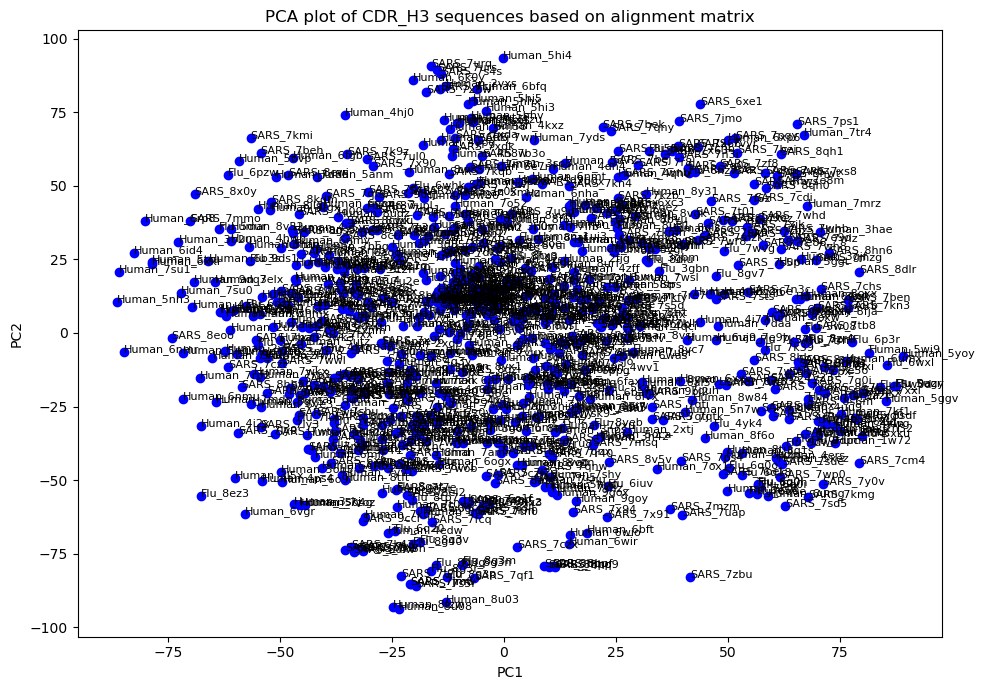

In [9]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

# 1. Load the alignment score matrix
matrix_file = r"C:\Users\clara\group04-team02\archive\cdr_h3_alignment_matrix.tsv"
matrix_df = pd.read_csv(matrix_file, sep="\t", index_col=0)

# 2. Extract IDs and matrix
ids = matrix_df.index.tolist()
Sreal = matrix_df.values
n = len(ids)

print(f"Loaded alignment matrix with shape {Sreal.shape}.")

# 3. Convert scores into distances
# A simple example: distances = -scores (larger scores = more similar)
# You can adapt this formula to your desired normalization
Dist = -Sreal

# Optionally, rescale so all distances >= 0
Dist -= Dist.min()

# 4. Embed distances via MDS
mds = MDS(n_components=10, dissimilarity="precomputed", random_state=42)
X_embedded = mds.fit_transform(Dist)

# 5. PCA on embedded coordinates
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_embedded)

# 6. Plot
plt.figure(figsize=(10,7))
plt.scatter(X_pca[:,0], X_pca[:,1], c='blue')
for i, txt in enumerate(ids):
    plt.annotate(txt, (X_pca[i,0], X_pca[i,1]), fontsize=8)

plt.title("PCA plot of CDR_H3 sequences based on alignment matrix")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


In [11]:
import pandas as pd
import numpy as np

# Define your CDR regions and paths
cdr_files = {
    "CDR_H1": r"C:\Users\clara\group04-team02\archive\cdr_h1_alignment_matrix.tsv",
    "CDR_H2": r"C:\Users\clara\group04-team02\archive\cdr_h2_alignment_matrix.tsv",
    "CDR_H3": r"C:\Users\clara\group04-team02\archive\cdr_h3_alignment_matrix.tsv",
}

# Loop over each CDR
for cdr_name, file_path in cdr_files.items():
    print(f"\nProcessing {cdr_name}...")

    # Load matrix
    df = pd.read_csv(file_path, sep="\t", index_col=0)

    # Extract IDs
    ids = df.index.tolist()
    organisms = [x.split("_")[0] for x in ids]
    unique_orgs = sorted(set(organisms))
    id_to_org = dict(zip(ids, organisms))

    print(f"Found organism groups: {unique_orgs}")

    # Initialize output mean matrix
    mean_matrix = pd.DataFrame(index=unique_orgs, columns=unique_orgs, dtype=float)

    # Compute mean alignment scores per organism pair
    for org1 in unique_orgs:
        ids1 = [id for id in ids if id_to_org[id] == org1]
        for org2 in unique_orgs:
            ids2 = [id for id in ids if id_to_org[id] == org2]

            submatrix = df.loc[ids1, ids2].values
            mean_score = np.mean(submatrix)
            mean_matrix.loc[org1, org2] = mean_score

    # Save this mean matrix
    outfile = rf"C:\Users\clara\group04-team02\archive\{cdr_name}_alignment_means.tsv"
    mean_matrix.to_csv(outfile, sep="\t")
    print(f"Saved mean matrix to {outfile}")

    # Optionally display
    print(mean_matrix)



Processing CDR_H1...
Found organism groups: ['Flu', 'Human', 'SARS']
Saved mean matrix to C:\Users\clara\group04-team02\archive\CDR_H1_alignment_means.tsv
             Flu      Human       SARS
Flu    10.685100  12.320475  10.730833
Human  12.320475  17.881705  15.281390
SARS   10.730833  15.281390  14.035140

Processing CDR_H2...
Found organism groups: ['Flu', 'Human', 'SARS']
Saved mean matrix to C:\Users\clara\group04-team02\archive\CDR_H2_alignment_means.tsv
            Flu     Human      SARS
Flu   -0.207700 -0.935013 -0.543783
Human -0.935013  0.096560 -0.410967
SARS  -0.543783 -0.410967  1.172756

Processing CDR_H3...
Found organism groups: ['Flu', 'Human', 'SARS']
Saved mean matrix to C:\Users\clara\group04-team02\archive\CDR_H3_alignment_means.tsv
           Flu     Human      SARS
Flu   -1.27030 -4.579420 -3.438770
Human -4.57942 -1.755028 -2.468484
SARS  -3.43877 -2.468484 -1.274005


In [12]:
import pandas as pd
import numpy as np

# Paths to your CDR alignment matrices
cdr_files = {
    "CDR_H1": r"C:\Users\clara\group04-team02\archive\cdr_h1_alignment_matrix.tsv",
    "CDR_H2": r"C:\Users\clara\group04-team02\archive\cdr_h2_alignment_matrix.tsv",
    "CDR_H3": r"C:\Users\clara\group04-team02\archive\cdr_h3_alignment_matrix.tsv",
}

# Initialize empty dictionary to hold feature DataFrames
feature_dict = {}

# Loop over CDRs
for cdr_name, file_path in cdr_files.items():
    print(f"\nProcessing {cdr_name}...")

    # Load matrix
    df = pd.read_csv(file_path, sep="\t", index_col=0)

    # Extract IDs
    ids = df.index.tolist()
    organisms = [x.split("_")[0] for x in ids]
    unique_orgs = sorted(set(organisms))
    id_to_org = dict(zip(ids, organisms))

    # Initialize output DataFrame
    feature_df = pd.DataFrame(index=ids)

    # For each organism group, compute the mean alignment score per sequence
    for target_org in unique_orgs:
        ids_target = [id for id in ids if id_to_org[id] == target_org]

        # Mean score to all sequences in target_org
        mean_scores = df.loc[:, ids_target].mean(axis=1)

        # Add column
        feature_df[f"{cdr_name}_mean_to_{target_org}"] = mean_scores

    # Store this DataFrame
    feature_dict[cdr_name] = feature_df

# Merge all CDR feature DataFrames horizontally
combined_features = pd.concat(feature_dict.values(), axis=1)

# Optionally, add organism label
combined_features["Organism"] = [x.split("_")[0] for x in combined_features.index]

# Save to TSV
outfile = r"C:\Users\clara\group04-team02\archive\cdr_per_sequence_mean_alignment_features.tsv"
combined_features.to_csv(outfile, sep="\t")

print(f"\nSaved per-sequence feature matrix to {outfile}")
print(combined_features.head())



Processing CDR_H1...

Processing CDR_H2...

Processing CDR_H3...

Saved per-sequence feature matrix to C:\Users\clara\group04-team02\archive\cdr_per_sequence_mean_alignment_features.tsv
           CDR_H1_mean_to_Flu  CDR_H1_mean_to_Human  CDR_H1_mean_to_SARS  \
SARS_9cci               14.41             19.767810            17.031746   
SARS_9ccj                8.21              2.984169             3.297619   
SARS_9bj2                3.83              6.535620             8.564815   
SARS_8z6r               13.89             20.730871            17.510582   
SARS_8z6s               13.89             20.730871            17.510582   

           CDR_H2_mean_to_Flu  CDR_H2_mean_to_Human  CDR_H2_mean_to_SARS  \
SARS_9cci              -3.905             -1.283641             0.379630   
SARS_9ccj               2.630             -1.664908             2.544974   
SARS_9bj2              -7.430             -7.573879            -9.486772   
SARS_8z6r              -1.785              1.175462 

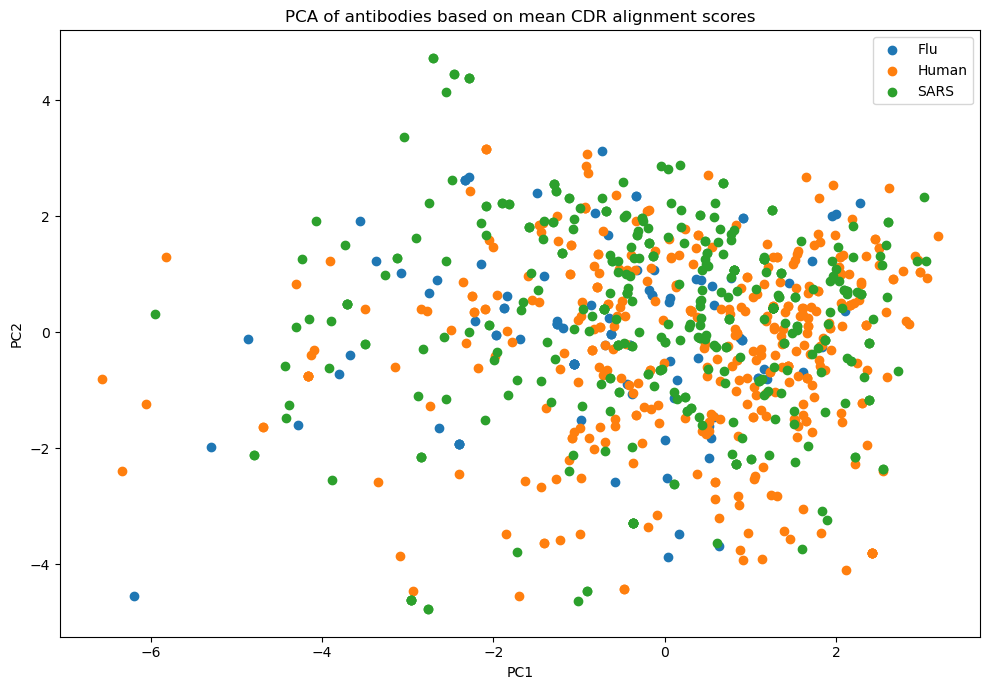

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load the table
df = pd.read_csv(outfile, sep="\t", index_col=0)

# Separate features and labels
X = df.drop(columns="Organism").values
y = df["Organism"].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10,7))
for label in np.unique(y):
    plt.scatter(X_pca[y==label,0], X_pca[y==label,1], label=label)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of antibodies based on mean CDR alignment scores")
plt.legend()
plt.tight_layout()
plt.show()


In [17]:
X_pca.shape == (n_sequences, 2)from sklearn.cluster import KMeans

# Choose number of clusters, e.g. 3
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X_pca)

# Plot
plt.figure(figsize=(10,7))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='tab10', s=50)
plt.title("K-means Clusters on PCA Embedding")
plt.xlabel("PC1")
plt.ylabel("PC2")

# Annotate points
for i, txt in enumerate(ids):
    plt.annotate(txt, (X_pca[i,0], X_pca[i,1]), fontsize=8)

plt.tight_layout()
plt.show()


SyntaxError: invalid syntax (2569046549.py, line 1)

           CDR_H1_mean_to_Flu  CDR_H1_mean_to_Human  CDR_H1_mean_to_SARS  \
SARS_9cci               14.41             19.767810            17.031746   
SARS_9ccj                8.21              2.984169             3.297619   
SARS_9bj2                3.83              6.535620             8.564815   
SARS_8z6r               13.89             20.730871            17.510582   
SARS_8z6s               13.89             20.730871            17.510582   

           CDR_H2_mean_to_Flu  CDR_H2_mean_to_Human  CDR_H2_mean_to_SARS  \
SARS_9cci              -3.905             -1.283641             0.379630   
SARS_9ccj               2.630             -1.664908             2.544974   
SARS_9bj2              -7.430             -7.573879            -9.486772   
SARS_8z6r              -1.785              1.175462             2.431217   
SARS_8z6s              -1.785              1.175462             2.431217   

           CDR_H3_mean_to_Flu  CDR_H3_mean_to_Human  CDR_H3_mean_to_SARS  \
SARS_9cci 

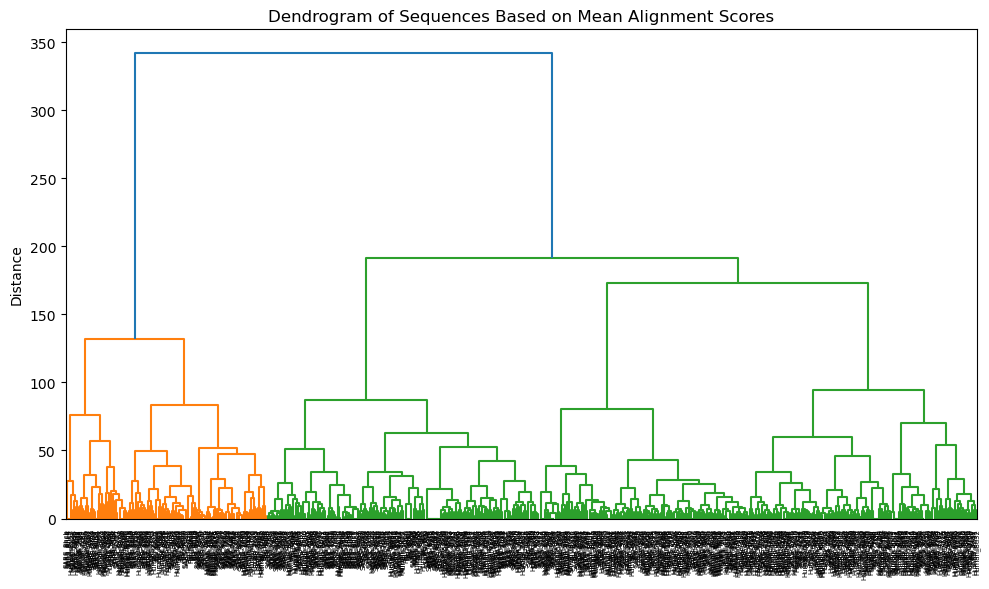

In [18]:
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Load your matrix
df = pd.read_csv(r"C:\Users\clara\group04-team02\archive\cdr_per_sequence_mean_alignment_features.tsv", sep="\t", index_col=0)

# Inspect the data
print(df.head())
print(df.dtypes)

# If you see something like:
# Organism     object
# CDR_H1_mean  float
# ...
# then exclude the non-numeric column.

# Option 1: If only first column is string
numeric_df = df.select_dtypes(include=[float, int])

# Option 2: If you know which columns are numeric
# numeric_df = df[["CDR_H1_mean", "CDR_H2_mean", "CDR_H3_mean"]]

# Compute linkage
Z = linkage(numeric_df.values, method='ward')

# Plot dendrogram
plt.figure(figsize=(10,6))
dendrogram(Z, labels=df.index, leaf_rotation=90)
plt.title("Dendrogram of Sequences Based on Mean Alignment Scores")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()



In [1]:
plt.figure(figsize=(10,6))
dendrogram(
    Z,
    labels=df.index,
    leaf_rotation=90,
    truncate_mode="level",  # show only the first N merges
    p=5                     # e.g., top 5 clusters
)
plt.title("Truncated Dendrogram (Top 5 Clusters)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


NameError: name 'plt' is not defined

In [21]:
from scipy.cluster.hierarchy import fcluster

# For example, form 5 clusters
cluster_labels = fcluster(Z, t=5, criterion='maxclust')

# Attach cluster labels to your DataFrame
df["Cluster"] = cluster_labels

print(df[["Cluster"]].value_counts())


Cluster
3          255
5          215
4          197
2          131
1           59
Name: count, dtype: int64


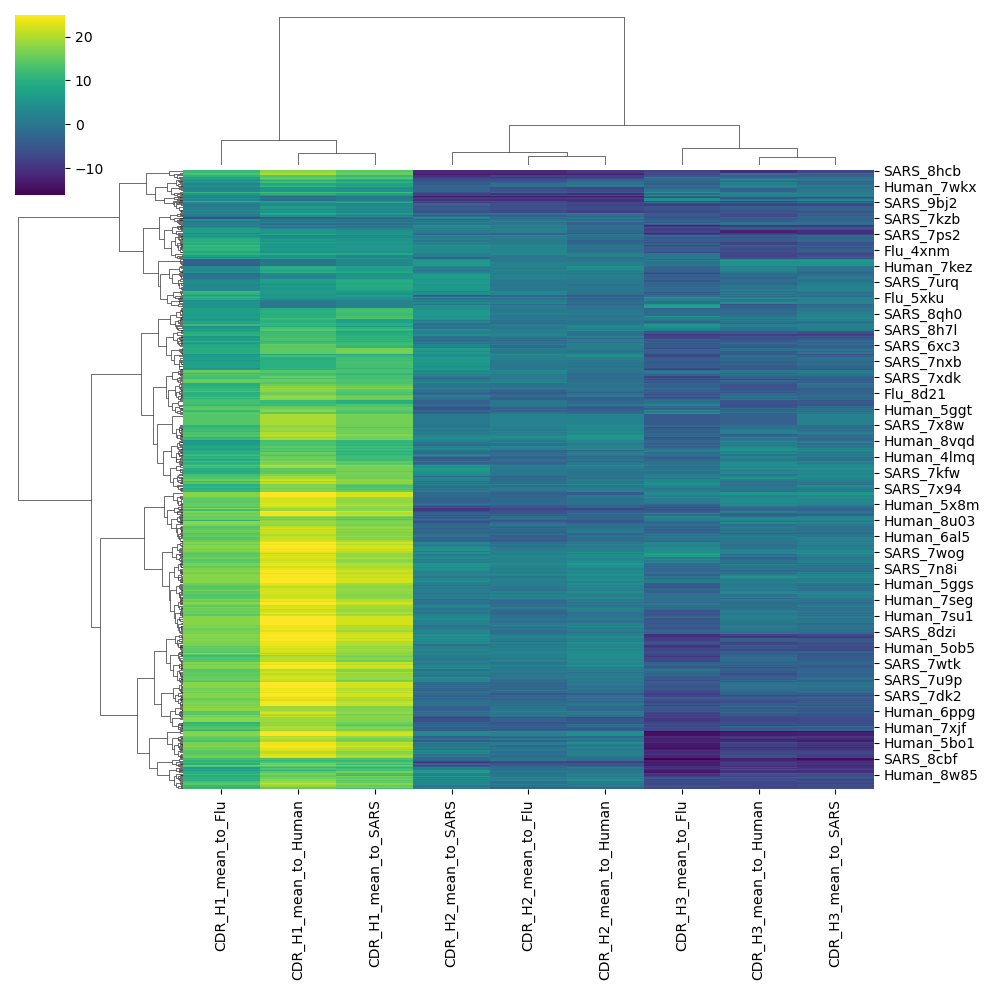

In [22]:
import seaborn as sns

sns.clustermap(
    df.select_dtypes(include=[float, int]),
    method="ward",
    metric="euclidean",
    cmap="viridis",
    figsize=(10,10)
)
plt.show()


In [24]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your combined mean alignment feature table
df = pd.read_csv(r"C:\Users\clara\group04-team02\archive\cdr_per_sequence_mean_alignment_features.tsv", index_col=0)

# 2. Separate labels (organism, IDs, etc) and numeric features
# Replace 'organism' and 'cdr_h3_length' with your actual label columns if different
label_cols = ['organism', 'cdr_id'] if 'cdr_id' in df.columns else ['organism']  # adjust as needed
labels = df[label_cols] if set(label_cols).issubset(df.columns) else None
numeric_df = df.drop(columns=label_cols, errors='ignore')

# 3. Standardize numeric features for clustering and PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)

# 4. Hierarchical clustering
Z = linkage(X_scaled, method='ward')

# 5. Assign cluster labels, e.g. 4 clusters
clusters = fcluster(Z, 4, criterion='maxclust')

# Add cluster info to dataframe
df['cluster'] = clusters

# 6. PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 7. Plot dendrogram (optional, can be large if many samples)
plt.figure(figsize=(10, 7))
dendrogram(Z, labels=df.index, leaf_rotation=90, leaf_font_size=6)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sequence ID')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# 8. Plot PCA colored by cluster
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['cluster'], palette='tab10')
plt.title('PCA of Mean Alignment Features')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

# 9. Analyze correlation with CDR length if available
if labels is not None and 'cdr_h3_length' in labels.columns:
    df['cdr_h3_length'] = labels['cdr_h3_length']

    # Boxplot of CDR length per cluster
    plt.figure(figsize=(8,6))
    sns.boxplot(x='cluster', y='cdr_h3_length', data=df)
    plt.title('CDR-H3 Length Distribution per Cluster')
    plt.xlabel('Cluster')
    plt.ylabel('CDR-H3 Length')
    plt.tight_layout()
    plt.show()

    # Correlation test
    from scipy.stats import spearmanr
    corr, pval = spearmanr(df['cdr_h3_length'], df['cluster'])
    print(f"Spearman correlation between CDR-H3 length and cluster: {corr:.3f} (p={pval:.3g})")

# 10. Output sequences in each cluster for interpretation
for clust in np.unique(clusters):
    print(f"\nCluster {clust} contains sequences:")
    print(df.index[df['cluster'] == clust].tolist())



ValueError: at least one array or dtype is required

### PCA

Für eine PCA, ist es sinnvoll die Alignment-Scores in Distanzen umzuwandeln


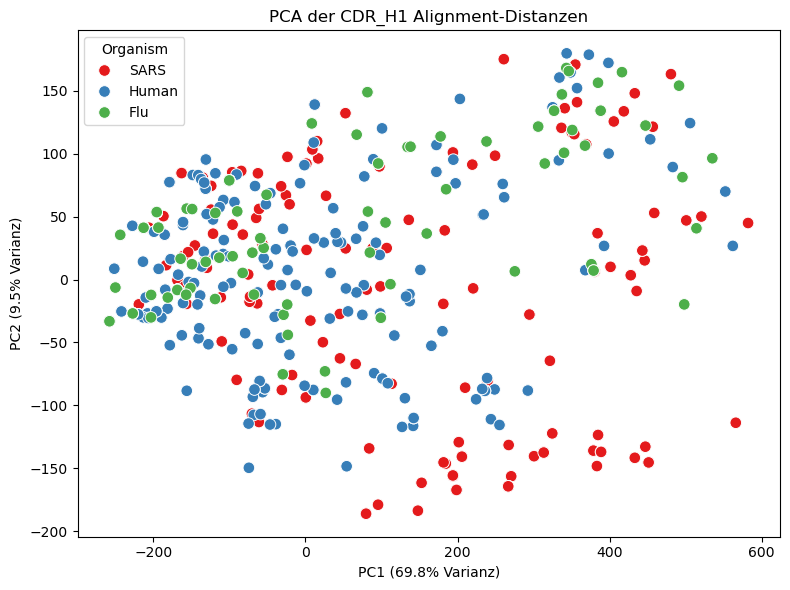

In [5]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Alignment-Score-Matrix einlesen
# Falls du schon `matrix_results` aus deinem Code hast, kannst du stattdessen direkt:
# score_df = matrix_results["CDR_H2"]

score_df = pd.read_csv("cdr_h1_alignment_matrix.tsv", sep="\t", index_col=0)

# 2️⃣ Distanzmatrix berechnen
# Wir nehmen als Distanz: max(Score) - Score
max_score = score_df.values.max()
distance_matrix = max_score - score_df.values

# 3️⃣ PCA berechnen
pca = PCA(n_components=2)
pcs = pca.fit_transform(distance_matrix)

# 4️⃣ DataFrame für Plot vorbereiten
ids = score_df.index.tolist()
organisms = [id.split("_")[0] for id in ids]

pca_df = pd.DataFrame({
    "PC1": pcs[:, 0],
    "PC2": pcs[:, 1],
    "ID": ids,
    "Organism": organisms
})

# 5️⃣ Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Organism",  # Farben nach Organismus
    palette="Set1",
    s=70
)
plt.title("PCA der CDR_H1 Alignment-Distanzen")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Varianz)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Varianz)")
plt.legend(title="Organism")
plt.tight_layout()
plt.show()


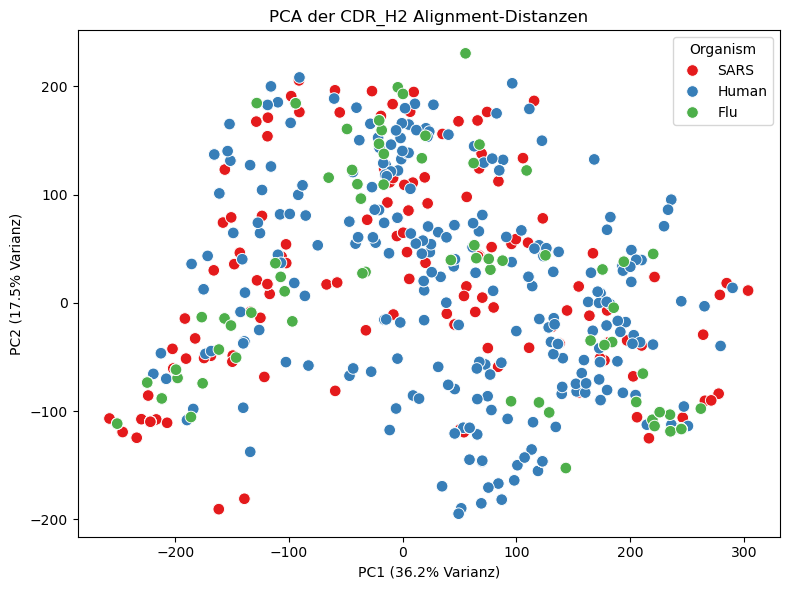

In [6]:
# 1️⃣ Alignment-Score-Matrix einlesen
# Falls du schon `matrix_results` aus deinem Code hast, kannst du stattdessen direkt:
# score_df = matrix_results["CDR_H2"]

score_df = pd.read_csv("cdr_h2_alignment_matrix.tsv", sep="\t", index_col=0)

# 2️⃣ Distanzmatrix berechnen
# Wir nehmen als Distanz: max(Score) - Score
max_score = score_df.values.max()
distance_matrix = max_score - score_df.values

# 3️⃣ PCA berechnen
pca = PCA(n_components=2)
pcs = pca.fit_transform(distance_matrix)

# 4️⃣ DataFrame für Plot vorbereiten
ids = score_df.index.tolist()
organisms = [id.split("_")[0] for id in ids]

pca_df = pd.DataFrame({
    "PC1": pcs[:, 0],
    "PC2": pcs[:, 1],
    "ID": ids,
    "Organism": organisms
})

# 5️⃣ Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Organism",  # Farben nach Organismus
    palette="Set1",
    s=70
)
plt.title("PCA der CDR_H2 Alignment-Distanzen")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Varianz)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Varianz)")
plt.legend(title="Organism")
plt.tight_layout()
plt.show()


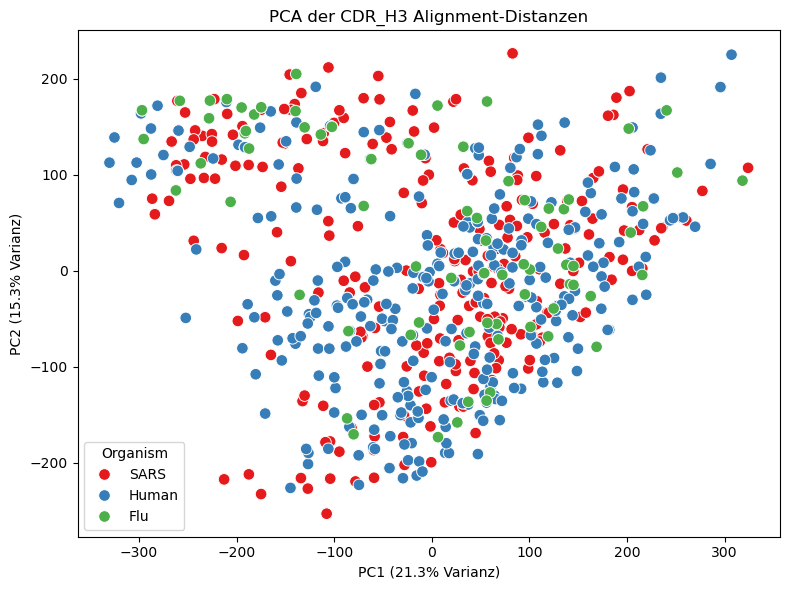

In [7]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Alignment-Score-Matrix einlesen
# Falls du schon `matrix_results` aus deinem Code hast, kannst du stattdessen direkt:
# score_df = matrix_results["CDR_H2"]

score_df = pd.read_csv("cdr_h3_alignment_matrix.tsv", sep="\t", index_col=0)

# 2️⃣ Distanzmatrix berechnen
# Wir nehmen als Distanz: max(Score) - Score
max_score = score_df.values.max()
distance_matrix = max_score - score_df.values

# 3️⃣ PCA berechnen
pca = PCA(n_components=2)
pcs = pca.fit_transform(distance_matrix)

# 4️⃣ DataFrame für Plot vorbereiten
ids = score_df.index.tolist()
organisms = [id.split("_")[0] for id in ids]

pca_df = pd.DataFrame({
    "PC1": pcs[:, 0],
    "PC2": pcs[:, 1],
    "ID": ids,
    "Organism": organisms
})

# 5️⃣ Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Organism",  # Farben nach Organismus
    palette="Set1",
    s=70
)
plt.title("PCA der CDR_H3 Alignment-Distanzen")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Varianz)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Varianz)")
plt.legend(title="Organism")
plt.tight_layout()
plt.show()


### K-means

de cuál ahhhhhh??????????????


In [ ]:
from sklearn.cluster import KMeans

# Wir nehmen dieselben PCs wie oben
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(pca_df[["PC1", "PC2"]])

# Labels zu DataFrame hinzufügen
pca_df["Cluster"] = labels

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=70
)
plt.title("k-Means Clustering der PCA (CDR_H2)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Varianz)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Varianz)")
plt.tight_layout()
plt.show()


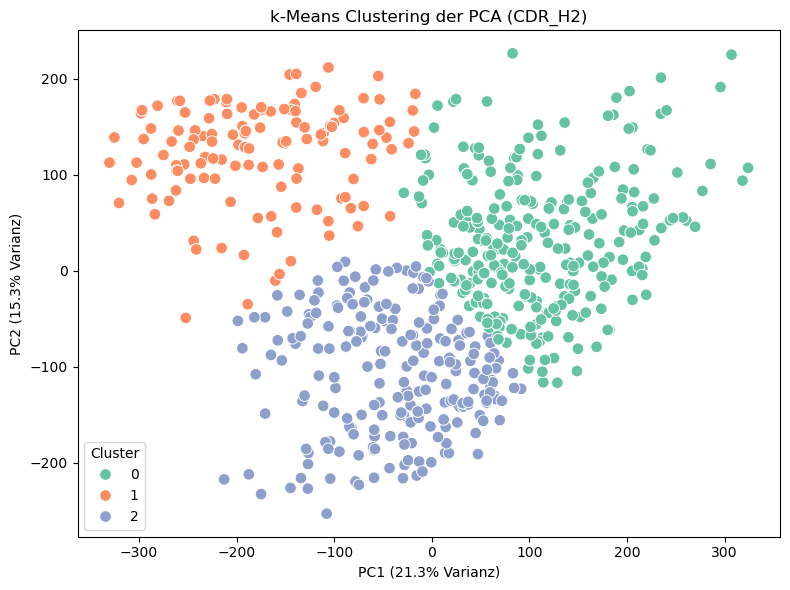

In [8]:
from sklearn.cluster import KMeans

# Wir nehmen dieselben PCs wie oben
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(pca_df[["PC1", "PC2"]])

# Labels zu DataFrame hinzufügen
pca_df["Cluster"] = labels

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=70
)
plt.title("k-Means Clustering der PCA (CDR_H2)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Varianz)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Varianz)")
plt.tight_layout()
plt.show()


### Hierarchisches Clsutering


### MDS der CDR Distanzen 